# Visualize State Embeddings

In [1]:
from argparse import Namespace

import torch
from torch_geometric.loader import DataLoader

from replay_parser.parser import parse_replay_dataset

from nn.state_encoder import GNNStateEncoderV2

/Users/pavankantharaju/Library/Caches/pypoetry/virtualenvs/microrts-analyzer-cZshM2hG-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/pavankantharaju/Library/Caches/pypoetry/virtualenvs/microrts-analyzer-cZshM2hG-py3.11/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/pavankantharaju/Library/Caches/pypoetry/virtualenvs/microrts-analyzer-cZshM2hG-py3.11/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a n

In [2]:
CONFIG = Namespace(
    seed=1,
    alpha=[0.99, 0.99],
    theta=[0.99, 0.99],
    device="cpu",
    run_name="run-0",
    ema_alpha=0.99,
    batch_size=8,
    model_name="microrts-gnn-state-encoder",
    save_model="gnn-state-model-v2-centering.pt",
    hidden_dims=256,
    max_replays=-1,
    update_freq=100,
    project_name="microrts-graph-state-encoder",
    learning_rate=0.0004,
    read_from_zip=True,
    ignore_players=["0"],
    # input_directory="../microrts-dataset/microrts-cog-2019-standard",
    input_directory="../microrts-dataset/COG2019-competition/microrts-cog-2019-dataset-last-2-iteration",
    lr_warmup_steps=1000,
    mixed_precision=None,
    allow_coordinate=False,
    max_scale_factor= 1.2,
    min_scale_factor=0.8,
    num_train_epochs=10,
    max_replay_length=64,
    state_representation='graph',
    lr_exp_schedule_gamma=0.99,
    unit_actions_to_ignore=[],
    grad_accumulation_steps=4,
    frame_skip_freq=10,
    frame_number_start=200
    )

CONFIG.rng = torch.Generator(CONFIG.device).manual_seed(CONFIG.seed)

### Construct Dataset

In [3]:
class BatchSampler(torch.utils.data.Sampler[list[int]]):
    """
    Custom batch sampler where each "batch" is the sequence of states
    from a single replay
    """
    def __init__(self, indices: list[int]):
        self.indices = indices

    def __len__(self) -> int:
        return len(self.indices)
    
    def __iter__(self):
        for idx in self.indices:
            yield idx
        # for i in range(len(self.indices)):
        #     yield self.indices[i]

def prepare_dataloader(config: Namespace):
    """
    Prepare dataloader

    :param config: Script config
    :returns Dataloader for state dataset, node dimensions, and edge dimensions
    """

    replay_data = parse_replay_dataset(config)

    node_dims = -1
    edge_dims = -1

    dataset = []
    dataset_indices = [] # List of list of indices
    state_index = 0

    for filename, pid, trace in replay_data:
        _, players, *_ = filename.split('.')
        player_1, _, player_2, *_ = players.split('-')
        players = [player_1, player_2]
        if players[pid] in config.ignore_players:
            # Don't add player data to dataset
            # print(filename, players, players[pid])
            continue

        trace_indices = []
        for state, _ in trace:

            if node_dims == -1:
                node_dims = state.x.shape[-1]

            if edge_dims == -1:
                edge_dims = state.edge_attr.shape[-1]

            dataset.append(state)
            trace_indices.append(state_index)
            state_index += 1
        dataset_indices.append(trace_indices)

    batch_sampler = BatchSampler(dataset_indices)
    return DataLoader(dataset, generator=config.rng, shuffle=False, batch_sampler=batch_sampler), \
        replay_data

In [4]:
dataloader, cog_replay_data = prepare_dataloader(CONFIG)

100%|██████████| 2112/2112 [04:54<00:00,  7.17it/s]


## Load Model

In [5]:
# Load model to evaluate

model_dict = torch.load(CONFIG.save_model)
ENCODER = GNNStateEncoderV2(10, 2, CONFIG.hidden_dims)
ENCODER.load_state_dict(model_dict)

# CONFIG.save_model = "gnn-replay-model-v4.pt"
# model_dict = torch.load(CONFIG.save_model)
# ENCODER = GNNReplayEncoder(10, 2, CONFIG.hidden_dims)
# ENCODER.load_state_dict(model_dict)

<All keys matched successfully>

In [6]:
from torch_geometric.transforms.normalize_features import NormalizeFeatures

graph_embeddings = None

game_segment_labels = []
map_labels = []
player_name_labels = []

map_id_to_name = {
    'map0': 'basesWorkers8x8A',
    'map1': 'basesWorkers16x16A',
    'map2': 'BWDistantResources32x32',
    'map3': 'BroodWar/(4)BloodBath.scmB',
    'map4': 'FourBasesWorkers8x8',
    'map5': 'TwoBasesBarracks16x16',
    'map6': 'NoWhereToRun9x8',
    'map7': 'DoubleGame24x24'
    }

pid_to_name = {
    '0': 'RandomBiasedAI',
    '1': 'POWorkerRush',
    '2': 'POLightRush',
    '3': 'NaiveMCTS',
    '4': 'Tiamat',
    '5': 'Droplet',
    '6': 'Izanagi',
    '7': 'MixedBot',
    '8': 'Hybrid_HTN_MCTS_Planner_Bot',
    '9': 'IDVRV_Bot',
    '10': 'CompetitionSarsaSearch',
    '11': 'UTS_Imass_SocketAI'
    }

norm_feature_fn = NormalizeFeatures(attrs=['x'])

for inst_idx, batch in enumerate(dataloader):
    filename, pid, trace = cog_replay_data[inst_idx]

    _, players, _, map_id = filename.split('.')
    player_1, _, player_2, *_ = players.split('-')
    players = [player_1, player_2]

    if players[pid] in CONFIG.ignore_players:
        # Don't add player data to dataset
        # print(filename, players, players[pid])
        continue

    _, _, map_id = map_id.split('-')

    player_name = pid_to_name[players[pid]]
    map_name = map_id_to_name[map_id]

    # player_name_labels.append(player_name)
    # map_labels.append(map_name)

    with torch.no_grad():
        norm_batch = norm_feature_fn(batch)
        state = norm_batch
        # _, replay_embedding, _ = ENCODER.state_encoder(
        #     state.x,
        #     state.edge_index,
        #     state.edge_attr,
        #     state.batch)

        _, replay_embedding, _ = ENCODER(
            state.x,
            state.edge_index,
            state.edge_attr,
            state.batch)

        # graph_embedding_1 = graph_embedding_1.unsqueeze(0)
        # graph_embedding = GNN_STATE_ENCODER.replay_encoder(graph_embedding_1)

        # replay_embedding = replay_embedding.squeeze(0)
        # replay_embedding = torch.mean(replay_embedding, dim=0).unsqueeze(0)

        segment_length = replay_embedding.shape[0] // 3
        # print(f"Segment length for replay with {replay_embedding.shape[0]} states: {segment_length}")
        for j in range(replay_embedding.shape[0]):
            player_name_labels.append(player_name)
            map_labels.append(map_name)
            if j < segment_length:
                # print(f"Early game: {j}")
                game_segment_labels.append('early-game')
            elif 2*segment_length > j >= segment_length:
                # print(f"Mid game: {j}")
                game_segment_labels.append('mid-game')
            else:
                # print(f"Late game: {j}")
                game_segment_labels.append('late-game')

        graph_embeddings = replay_embedding if graph_embeddings is None \
            else torch.concatenate([graph_embeddings, replay_embedding], dim=0)

graph_embeddings = graph_embeddings.numpy()

In [7]:
print(f"Number of states: {graph_embeddings.shape[0]}")

Number of states: 23883


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=2.5)
plt.set_cmap('tab20')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

import pandas as pd
import numpy as np

from sklearn_extra.cluster import KMedoids

<Figure size 640x480 with 0 Axes>

## Find optimal number of clusters based on elbow method

Silhouette Score for 3 clusters: 0.4081922769546509
Silhouette Score for 4 clusters: 0.3162153959274292
Silhouette Score for 5 clusters: 0.30515897274017334
Silhouette Score for 6 clusters: 0.3330269157886505
Silhouette Score for 7 clusters: 0.31483739614486694
Silhouette Score for 8 clusters: 0.30227717757225037
Silhouette Score for 9 clusters: 0.3062986135482788


/Users/pavankantharaju/Library/Caches/pypoetry/virtualenvs/microrts-analyzer-cZshM2hG-py3.11/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 9 is empty! self.labels_[self.medoid_indices_[9]] may not be labeled with its corresponding cluster (9).
  warnings.warn(


Silhouette Score for 10 clusters: 0.29396241903305054


/Users/pavankantharaju/Library/Caches/pypoetry/virtualenvs/microrts-analyzer-cZshM2hG-py3.11/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 9 is empty! self.labels_[self.medoid_indices_[9]] may not be labeled with its corresponding cluster (9).
  warnings.warn(


Silhouette Score for 11 clusters: 0.3071829378604889


...

Silhouette Score for 13 clusters: 0.2634302079677582


/Users/pavankantharaju/Library/Caches/pypoetry/virtualenvs/microrts-analyzer-cZshM2hG-py3.11/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 12 is empty! self.labels_[self.medoid_indices_[12]] may not be labeled with its corresponding cluster (12).
  warnings.warn(


Silhouette Score for 14 clusters: 0.2611798048019409


/Users/pavankantharaju/Library/Caches/pypoetry/virtualenvs/microrts-analyzer-cZshM2hG-py3.11/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 12 is empty! self.labels_[self.medoid_indices_[12]] may not be labeled with its corresponding cluster (12).
  warnings.warn(


Silhouette Score for 15 clusters: 0.2532883584499359


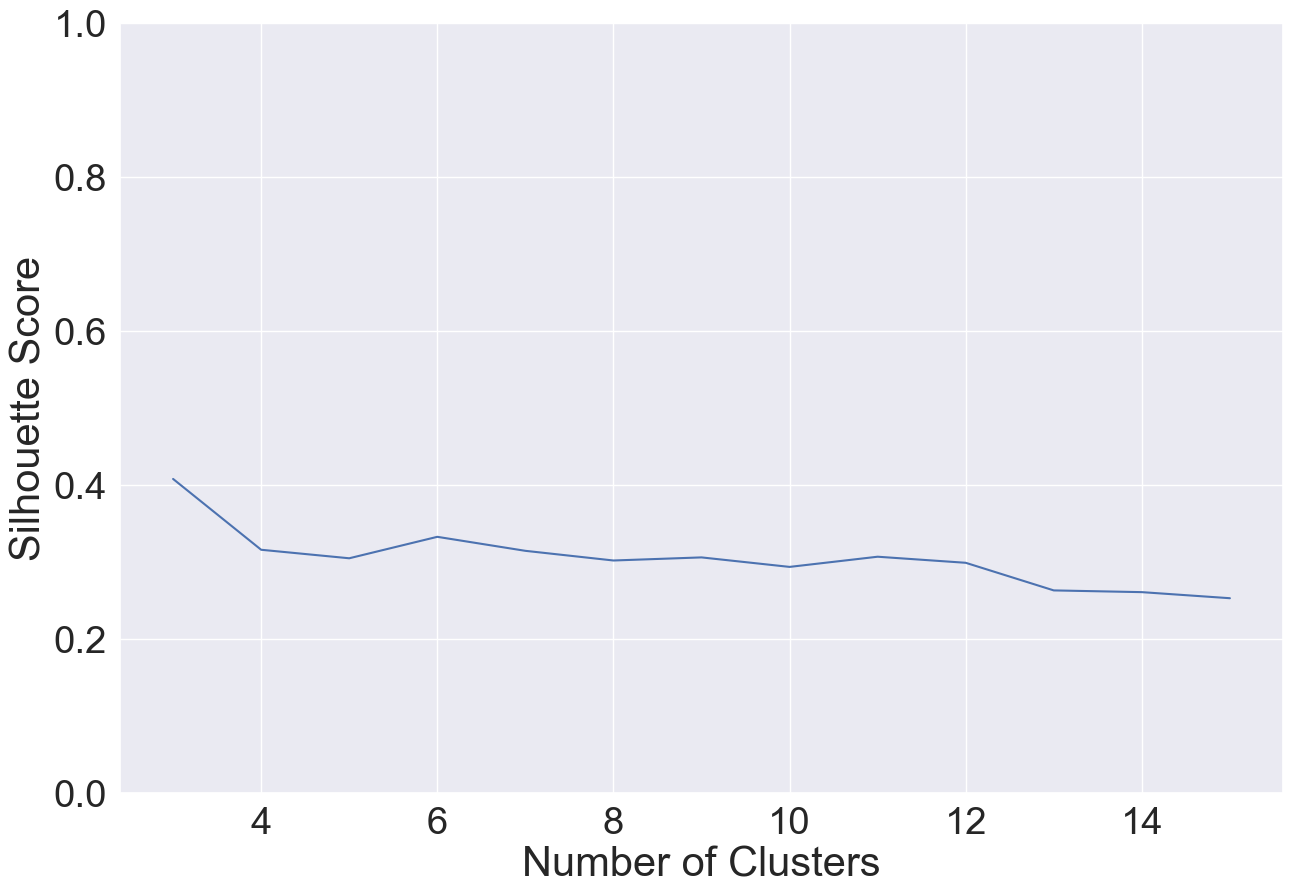

In [11]:
from sklearn.metrics import silhouette_score

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111)

silhouette_score_df = []
for n_clusters in range(3, 16):
    kmedoids_obj = KMedoids(n_clusters=n_clusters)
    kmedoids_obj.fit(graph_embeddings)

    score = silhouette_score(graph_embeddings, kmedoids_obj.labels_)
    print(f"Silhouette Score for {n_clusters} clusters: {score}")
    silhouette_score_df.append([n_clusters, score])

silhouette_score_df = pd.DataFrame(silhouette_score_df,
                                   columns=['num_clusters', 'silhouette_score'])

sns.lineplot(data=silhouette_score_df, x='num_clusters', y='silhouette_score',
             ax=ax)

ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Silhouette Score")
ax.set_ylim(0, 1.0)
# box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])
# ax.legend(loc='center left', bbox_to_anchor=(1.15, 0.5))

if CONFIG.max_replays == -1:
    plt.savefig('cog-2019-all-replays-silhouette.pdf', bbox_inches='tight')
    silhouette_score_df.to_csv('cog-2019-all-replays-silhouette.csv')
else:
    plt.savefig(f'cog-2019-first-{CONFIG.max_replays}-replays-silhouette.pdf', bbox_inches='tight')
    silhouette_score_df.to_csv(f'cog-2019-first-{CONFIG.max_replays}-replays-silhouette.csv')

In [12]:
kmedoids_obj = KMedoids(n_clusters=7)
kmedoids_obj.fit(graph_embeddings)

KMedoids(n_clusters=7)

## Plot graph embeddings

/var/folders/8p/l0sfh_s15_s_5rk6np4yvwn00000gn/T/ipykernel_84131/3745061537.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(label_df.dim1, label_df.dim2, label=str(label), c=color_map(i))


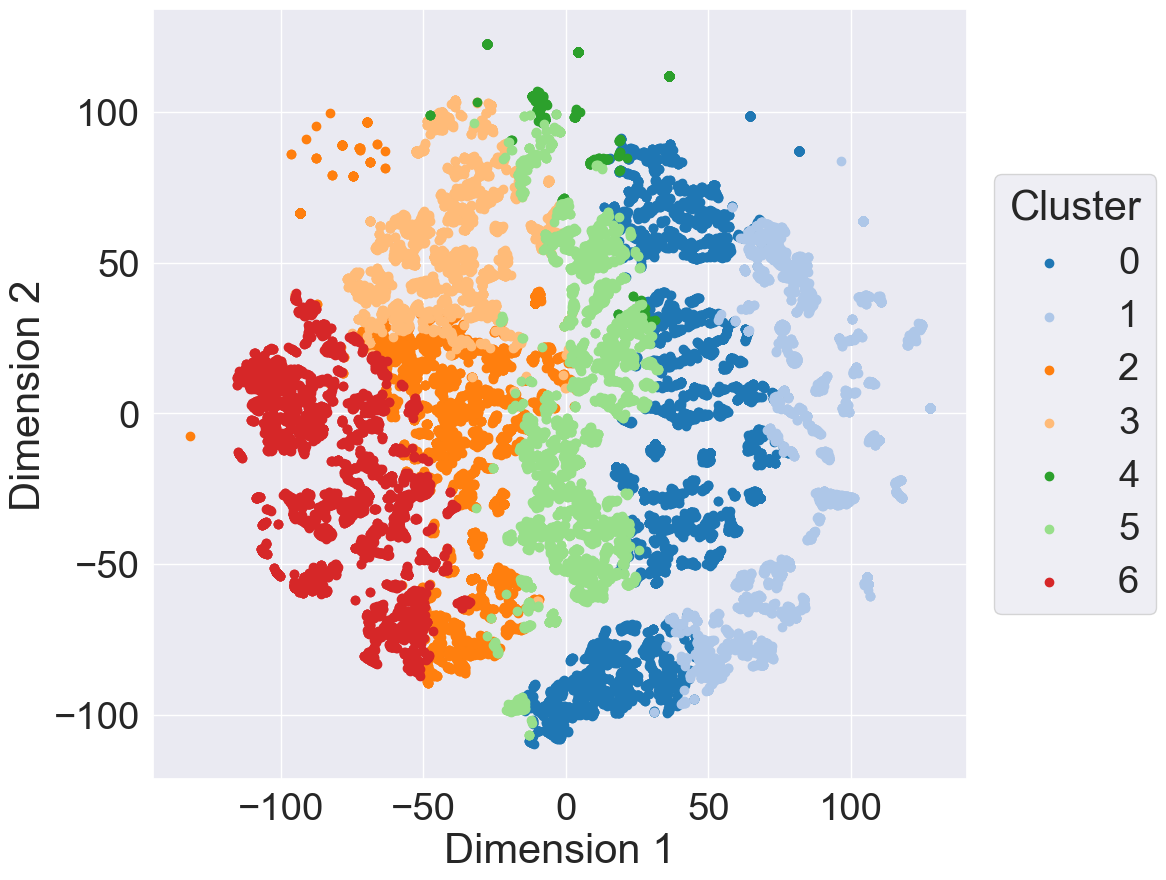

In [13]:
color_map = plt.get_cmap('tab20')

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111)
# ax = fig.add_subplot(111, projection='3d')

# dim_red_obj = UMAP(n_components=2, random_state=CONFIG.seed)
dim_red_obj = TSNE(n_components=2, random_state=CONFIG.seed)
dim_red_embedding = dim_red_obj.fit_transform(graph_embeddings)

df = pd.DataFrame(dim_red_embedding, columns=['dim1', 'dim2'])
df['game_segment_label'] = game_segment_labels
df['map_label'] = map_labels
df['kmedoids_label'] = kmedoids_obj.labels_
df['player_name'] = player_name_labels

labels = df['kmedoids_label'].values
# labels = [label for label in labels if 'mid-game' not in label]
num_labels = len(set(labels))
for i, label in enumerate(set(labels)):
    label_df = df[df.kmedoids_label == label]
    ax.scatter(label_df.dim1, label_df.dim2, label=str(label), c=color_map(i))

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
# ax.set_zlabel("Dimension 3")
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), title='Cluster')

if CONFIG.max_replays == -1:
    plt.savefig('cog-2019-all-replays-cluster-vis.pdf', bbox_inches='tight')
else:
    plt.savefig(f'cog-2019-first-{CONFIG.max_replays}-replays-cluster-vis.pdf', bbox_inches='tight')

# plt.close(fig)

## Compute feature metrics for each cluster

In [14]:
from torch_geometric.utils.unbatch import unbatch_edge_index

from replay_parser.state import UNIT_TYPES

unit_types_no_resources = UNIT_TYPES[:]
unit_types_no_resources.remove('resource')

# cluster_metrics = {}
cluster_unit_counts_df = []
cluster_additional_metrics_df = []

label_idx = 0
for inst_idx, batch in enumerate(dataloader):

    filename, pid, trace = cog_replay_data[inst_idx]

    _, players, _, map_id = filename.split('.')
    player_1, _, player_2, *_ = players.split('-')
    players = [player_1, player_2]
    _, _, map_id = map_id.split('-')

    if players[pid] in CONFIG.ignore_players:
        # Don't add player data to dataset
        # print(filename, players, players[pid])
        continue

    unbatched_edge_indices = unbatch_edge_index(batch.edge_index, batch.batch)
    edge_index = 0

    for i in range(batch.batch.max()+1):

        cluster_label = kmedoids_obj.labels_[label_idx]
        label_idx += 1

        cluster_additional_metrics_df.append([
            cluster_label, 'map_name', map_id_to_name[map_id]
            ])

        indices = torch.where(batch.batch == i)[0]
        graph_nodes = batch.x[indices, :]
        num_states = graph_nodes.shape[0]
        num_edges = unbatched_edge_indices[i].shape[1]

        for j in range(num_edges):
            src_node_index = unbatched_edge_indices[i][0][j]
            if int(graph_nodes[src_node_index][-1]) == 1:
                cluster_additional_metrics_df.append(
                    [cluster_label, 'distance', batch.edge_attr[edge_index, 0].item()])
                cluster_additional_metrics_df.append(
                    [cluster_label, 'angle', batch.edge_attr[edge_index, 1].item()])
            # cluster_metrics[cluster_label]['distance'].append(
            #     batch.edge_attr[edge_index, 0].item())
            # cluster_metrics[cluster_label]['angle'].append(
            #      batch.edge_attr[edge_index, 1])
            edge_index += 1
        
        for state_idx in range(num_states):
            if int(graph_nodes[state_idx][6]) == 1:
                cluster_additional_metrics_df.append(
                    [cluster_label, 'map-resources', graph_nodes[state_idx][-3].item()])
                continue

            if int(graph_nodes[state_idx][-1]) == 1:
                for j, unit_type in enumerate(unit_types_no_resources):
                    cluster_unit_counts_df.append(
                        [cluster_label, unit_type, graph_nodes[state_idx][j].item()])

                cluster_additional_metrics_df.append(
                    [cluster_label, 'hitpoints', graph_nodes[state_idx][-2].item()])

cluster_unit_counts_df = pd.DataFrame(cluster_unit_counts_df,
                                      columns=['cluster_num', 'metric', 'score'])

cluster_additional_metrics_df = pd.DataFrame(cluster_additional_metrics_df,
                                             columns=['cluster_num', 'metric', 'score'])

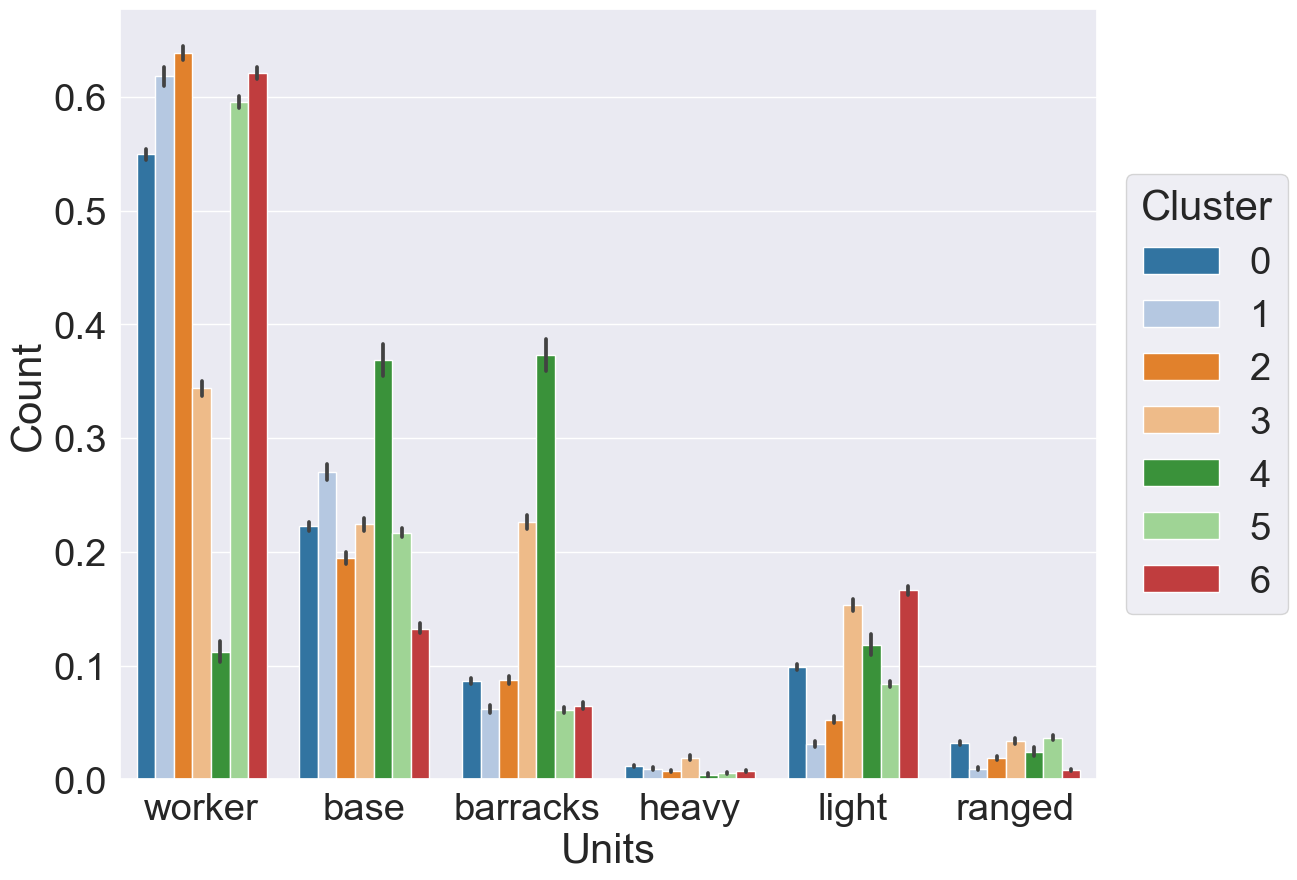

In [15]:
fig = plt.figure(figsize=(18, 10))
ax = fig.add_subplot(1,1,1)

sns.set_palette('tab20')

sns.barplot(data=cluster_unit_counts_df, x='metric', y='score', hue='cluster_num', ax=ax)

ax.set_xlabel("Units")
ax.set_ylabel("Count")

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), title='Cluster')
# plt.close(fig)

if CONFIG.max_replays == -1:
    plt.savefig('cog-2019-all-replays-unit-counts.pdf', bbox_inches='tight')
else:
    plt.savefig(f'cog-2019-first-{CONFIG.max_replays}-replays-unit-counts.pdf', bbox_inches='tight')


Cluster 0: Map Resources: 13.060201261427256, Distance: 13.430821875277504
Cluster 1: Map Resources: 12.895953079178886, Distance: 15.706404402533678
Cluster 2: Map Resources: 21.058687213950524, Distance: 14.252527855264534
Cluster 3: Map Resources: 16.379814814814814, Distance: 11.337838247821365
Cluster 4: Map Resources: 15.54245150407647, Distance: 12.310502488538944
Cluster 5: Map Resources: 13.173083915801381, Distance: 10.745525006142987
Cluster 6: Map Resources: 27.349537426408748, Distance: 29.678430134962287


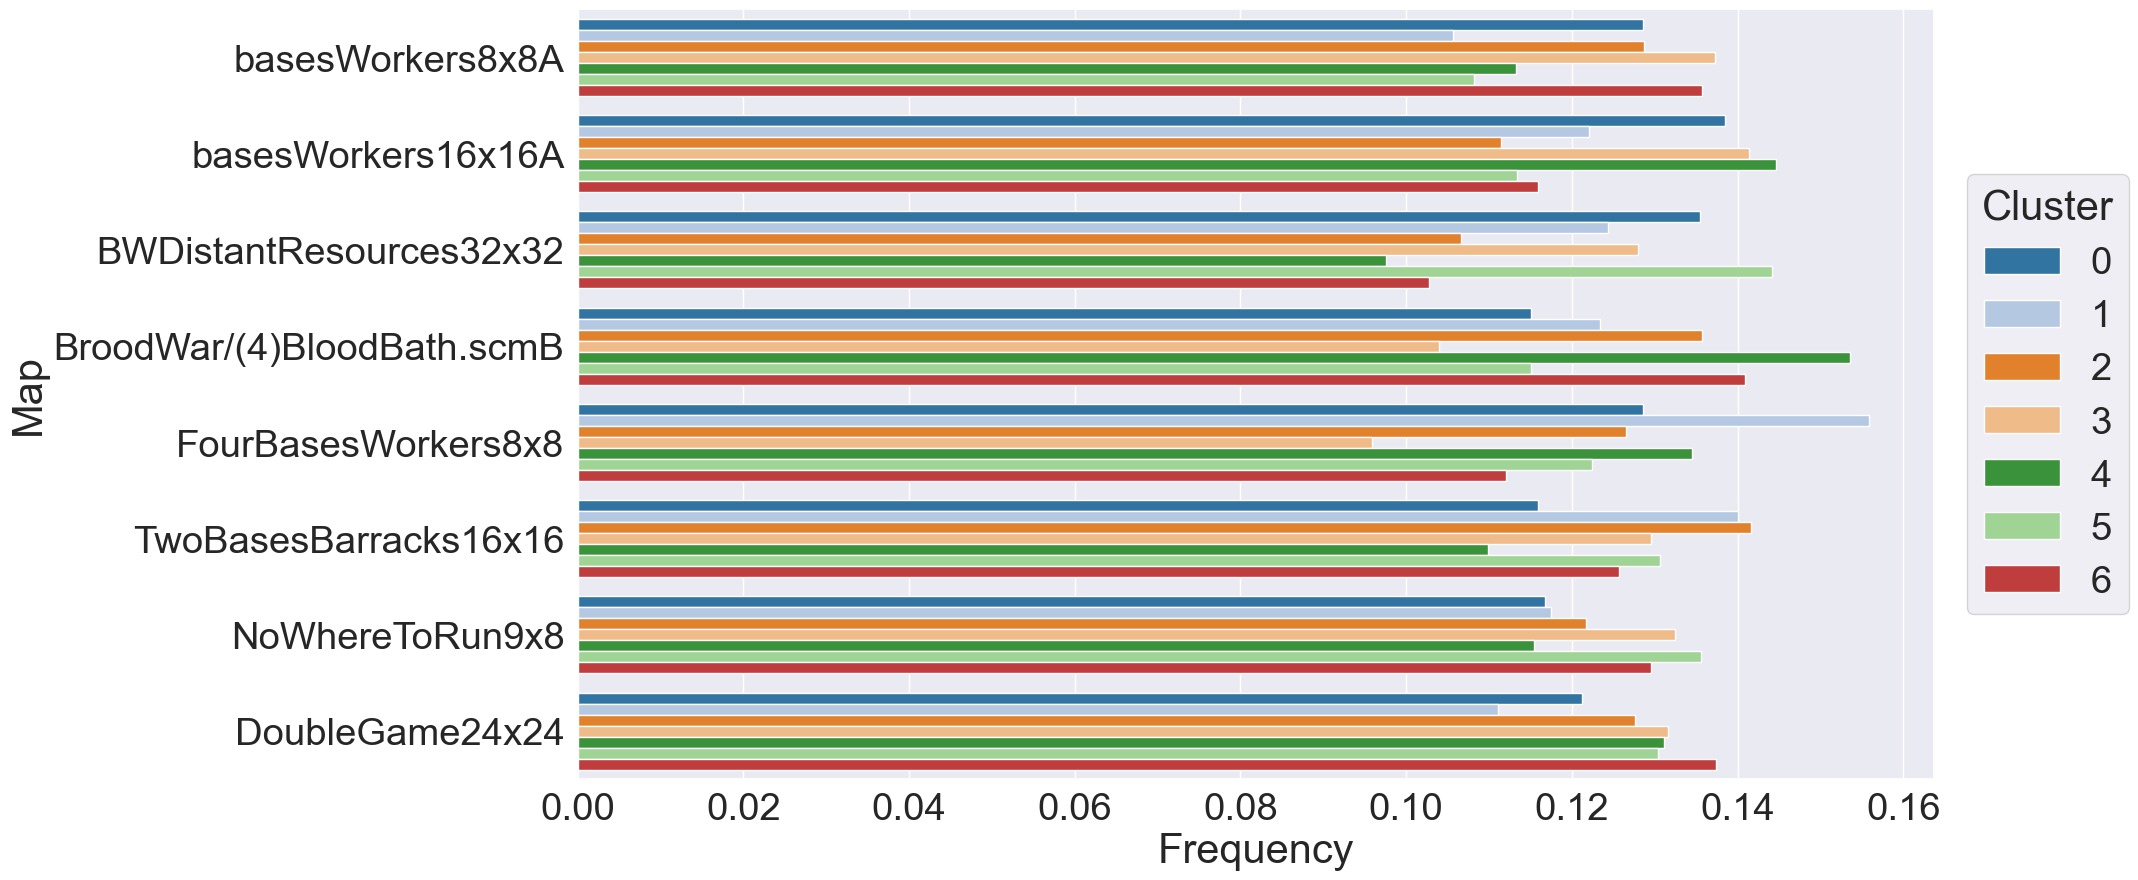

In [16]:
max_cluster_number = cluster_additional_metrics_df.cluster_num.values.max()

map_distribution_df = []

for i in range(max_cluster_number+1):
    cluster_df = cluster_additional_metrics_df[cluster_additional_metrics_df.cluster_num == i]
    avg_map_resources = cluster_df[cluster_df.metric.str.fullmatch('map-resources')].score.mean()
    avg_distance = cluster_df[cluster_df.metric.str.fullmatch('distance')].score.mean()
    # avg_angle = cluster_df[cluster_df.metric.str.fullmatch('angle')].score.mean()
    print(f"Cluster {i}: Map Resources: {avg_map_resources}, Distance: {avg_distance}")

    map_name_df = cluster_df[cluster_df.metric.str.fullmatch('map_name')]
    total_count = 0
    map_cluster_dist_df = []
    for map_name in map_id_to_name.values():
        if map_name == 'BroodWar/(4)BloodBath.scmB':
            count_df = map_name_df[map_name_df.score.str.match('BroodWar')]
        else:
            count_df = map_name_df[map_name_df.score.str.fullmatch(map_name)]
        count = count_df.shape[0]
        total_count += count
        map_cluster_dist_df.append([i, map_name, count])

    map_cluster_dist_df = list(map(lambda x: [x[0], x[1], x[2]/total_count], map_cluster_dist_df))
    map_distribution_df += map_cluster_dist_df

map_distribution_df = pd.DataFrame(map_distribution_df, columns=['cluster_num', 'map_name', 'frequency'])

fig = plt.figure(figsize=(25, 10))
ax = fig.add_subplot(1,1,1)

sns.barplot(data=map_distribution_df, y='map_name', x='frequency', hue='cluster_num',
            orient='h', ax=ax)

ax.set_xlabel("Frequency")
ax.set_ylabel("Map")

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), title='Cluster')

# box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])
# ax.legend(loc='center left', bbox_to_anchor=(1.15, 0.5))
# plt.close(fig)

if CONFIG.max_replays == -1:
    plt.savefig(f'cog-2019-all-replays-map-distribution.pdf', bbox_inches='tight')
else:
    plt.savefig(f'cog-2019-first-{CONFIG.max_replays}-replays-map-distribution.pdf', bbox_inches='tight')

## Valley of Old Code

In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity

# sim = cosine_similarity(graph_embeddings, graph_embeddings)
# flattened_sim = sim.reshape(-1)

# plt.hist(flattened_sim, bins=10, range=(-1, 1))
# plt.show()